In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 

Q1

In [5]:
df1 = pd.read_csv('Question2.csv')
df1.head(3)

,ID,Game,Goal,Position,Foot
0,1,1,Yes,LC,Right
1,2,2,Yes,HR,Right
2,3,3,Yes,MR,Right


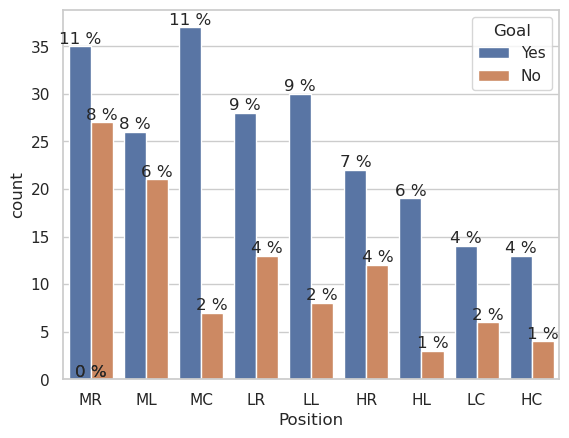

In [17]:
sns.set_theme(style="whitegrid")


ax = sns.countplot(x = df1.Position , hue = df1.Goal , order= df1.Position.value_counts().index )
total = len(df1.Position)
for p in ax.patches : 
    h = p.get_height()
    ax.annotate(f"{round(float(h/total)*100)} %" , (p.get_x() + p.get_width() / 2 , h) , ha = 'center' , va = 'bottom')


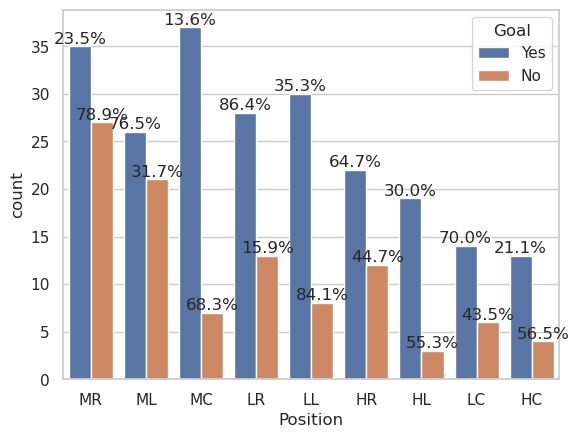

In [22]:
import pandas as pd
import seaborn as sns

ax = sns.countplot(
    x="Position",
    hue="Goal",
    data=df1,
    order=df1["Position"].value_counts().index
)

# cross-tab counts
ct = pd.crosstab(df1["Position"], df1["Goal"])

for i, position in enumerate(ct.index):
    total = ct.loc[position].sum()
    
    for j, goal in enumerate(ct.columns):
        count = ct.loc[position, goal]
        percentage = (count / total) * 100
        
        # find corresponding bar
        p = ax.patches[i * len(ct.columns) + j]
        
        ax.annotate(
            f"{percentage:.1f}%",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom'
        )

<Axes: xlabel='Main_area', ylabel='count'>

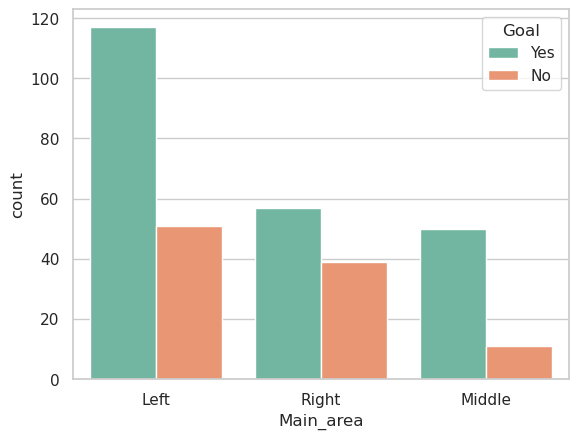

In [19]:
data = df1.copy()
if df1.Position.str.contains('L').any():
        df1['Main_area'] = df1.Position.apply(lambda x: 'Left' if 'L' in x else ('Middle' if 'C' in x else 'Right'))
plt.style.use('fast')

sns.countplot(x = data.Main_area , hue =data.Goal , palette= 'Set2',order=data.Main_area.value_counts().index   )


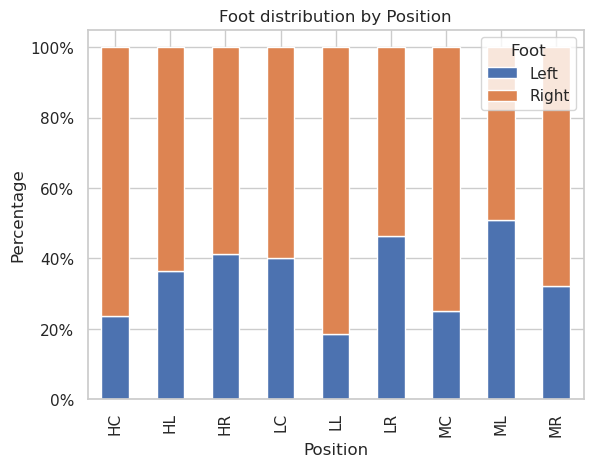

In [20]:
  
import matplotlib.ticker as mtick

    # compute percentages
df = (
        data.groupby(['Position', 'Foot'])
        .size()
        .groupby(level=0,group_keys=False)
        .apply(lambda x: x / x.sum())
        .reset_index(name='pct')
    )

    # pivot for stacking
pivot = df.pivot(index='Position', columns='Foot', values='pct')

    # plot stacked bars
pivot.plot(kind='bar', stacked=True)

    # format
plt.ylabel('Percentage')
plt.xlabel('Position')
plt.title('Foot distribution by Position')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.legend(title='Foot')
plt.show()

<Axes: xlabel='Position', ylabel='count'>

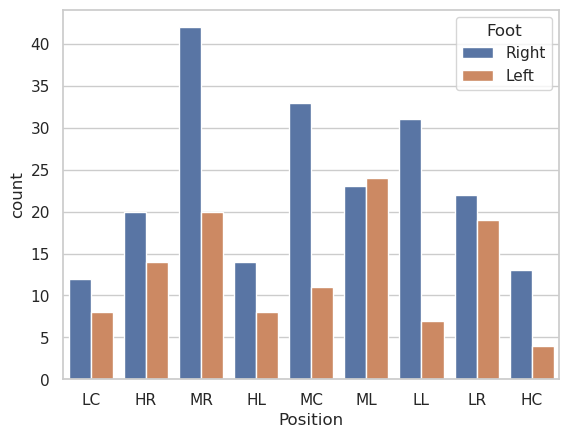

In [21]:
sns.countplot(x = df1.Position , hue = df1.Foot )

Q2

In [6]:
df2 = pd.read_csv('Question3.csv')
df2.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


/tmp/ipykernel_15561/479229062.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2.groupby(["Position", "Goal"])
/tmp/ipykernel_15561/479229062.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_a["pct"] = df_a.groupby("Position")["n"].transform(lambda x: x / x.sum())


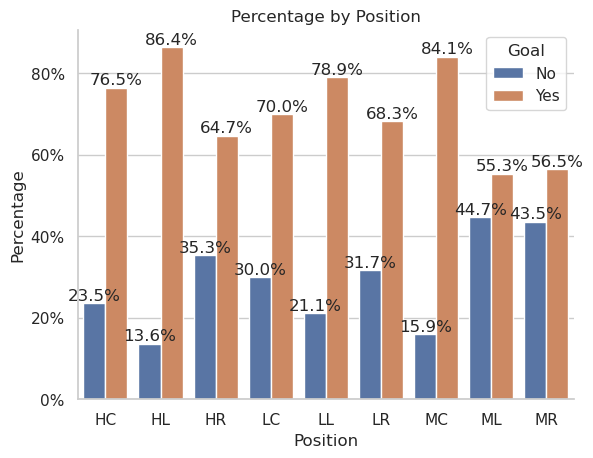

/tmp/ipykernel_15561/479229062.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2.groupby(["Area", "Goal"])
/tmp/ipykernel_15561/479229062.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_b["pct"] = df_b.groupby("Area")["n"].transform(lambda x: x / x.sum())


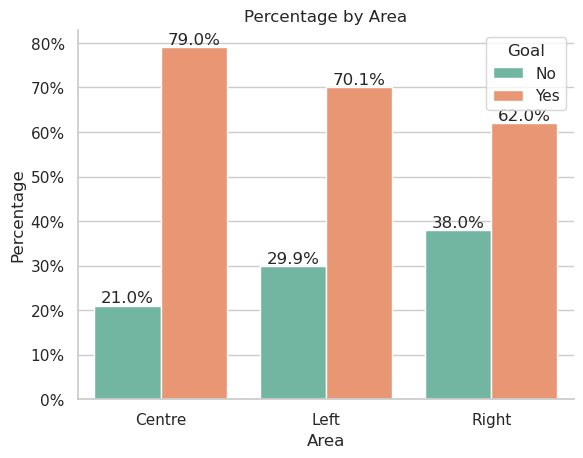

/tmp/ipykernel_15561/479229062.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q2.groupby(["Position", "Foot"])
/tmp/ipykernel_15561/479229062.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c["pct"] = df_c.groupby("Position")["n"].transform(lambda x: x / x.sum())


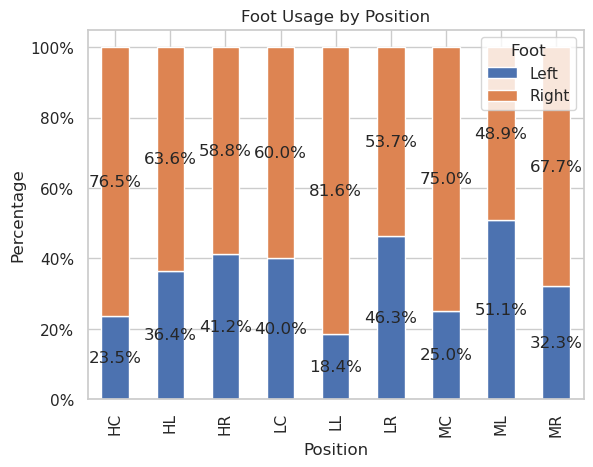

Chi-square test
X-squared = 16.06877435233638
df = 8
p-value = 0.041406251336907014

Fisher test not applicable for tables larger than 2x2 in scipy.


In [ ]:
# Preparing the data set
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

q2 = pd.read_csv("Question2.csv")

# Convert to categorical
q2["Goal"] = q2["Goal"].astype("category")
q2["Position"] = q2["Position"].astype("category")
q2["Foot"] = q2["Foot"].astype("category")


### Part A ###
# Ideally I want something similar to this

# Group + count + percentage
df_a = (
    q2.groupby(["Position", "Goal"])
    .size()
    .reset_index(name="n")
)

df_a["pct"] = df_a.groupby("Position")["n"].transform(lambda x: x / x.sum())

# Plot
plt.figure()
ax = sns.barplot(data=df_a, x="Position", y="pct", hue="Goal")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in container.datavalues])

plt.ylabel("Percentage")
plt.xlabel("Position")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.title("Percentage by Position")
sns.despine()
plt.show()


#### Part B ####

### creating a new variable for areas
q2["Area"] = q2["Position"].apply(
    lambda x: "Centre" if x in ["HC", "LC", "MC"]
    else ("Right" if x in ["HR", "LR", "MR"] else "Left")
).astype("category")

df_b = (
    q2.groupby(["Area", "Goal"])
    .size()
    .reset_index(name="n")
)

df_b["pct"] = df_b.groupby("Area")["n"].transform(lambda x: x / x.sum())

# Plot
plt.figure()
ax = sns.barplot(data=df_b, x="Area", y="pct", hue="Goal", palette="Set2")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in container.datavalues])

plt.ylabel("Percentage")
plt.xlabel("Area")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.title("Percentage by Area")
sns.despine()
plt.show()


#### Part C #####
df_c = (
    q2.groupby(["Position", "Foot"])
    .size()
    .reset_index(name="n")
)

df_c["pct"] = df_c.groupby("Position")["n"].transform(lambda x: x / x.sum())

# Stacked bar plot
pivot_c = df_c.pivot(index="Position", columns="Foot", values="pct")

pivot_c.plot(kind="bar", stacked=True)

# Add labels manually
for i, row in enumerate(pivot_c.values):
    cumulative = 0
    for val in row:
        if pd.notna(val):
            plt.text(i, cumulative + val/2, f"{val*100:.1f}%", ha='center', va='center')
            cumulative += val

plt.ylabel("Percentage")
plt.xlabel("Position")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.title("Foot Usage by Position")
plt.show()


#### Part D  ####
# The discussion should refer to the objectives:
# a) You should mention the positions with the highest scoring probability
# b) You should mention the positions with the lowest scoring probability
# d) You should mention the area with the highest scoring probability
# e) You should mention the area with the lowest scoring probability
# f) You should indicate from the stacked plot the major tendencies
# in the relationship between the foot used and the area
# g) Give your main recommendations


#### Bonus #####
# We can easily test the association between two categorical variables
# using the Chi-squared or Fisher's exact tests of association

from scipy.stats import chi2_contingency, fisher_exact

# Chi-square test
table = pd.crosstab(q2["Position"], q2["Foot"])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square test")
print("X-squared =", chi2)
print("df =", dof)
print("p-value =", p)

# the results of the test suggest an association between
# the position of the shot on the goal and the foot used
# at 0.05 level of significance if p < 0.05


##### Fisher's Exact test
# NOTE: Fisher only works for 2x2, so this is a limitation in Python
# For larger tables, simulation is not built-in like R

if table.shape == (2, 2):
    oddsratio, p_fisher = fisher_exact(table)
    print("\nFisher's Exact test p-value =", p_fisher)
else:
    print("\nFisher test not applicable for tables larger than 2x2 in scipy.")

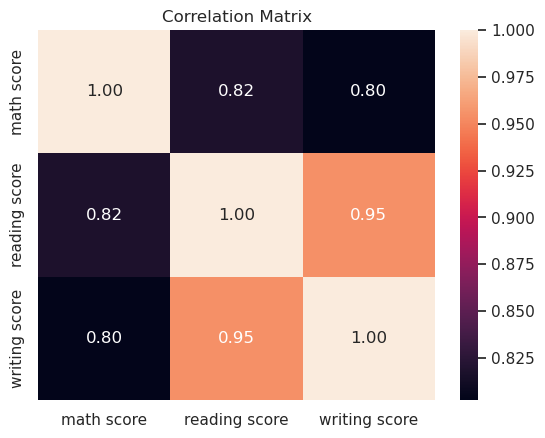

Correlation (r):
               math score  reading score  writing score
math score         1.0000         0.8176         0.8026
reading score      0.8176         1.0000         0.9546
writing score      0.8026         0.9546         1.0000

P-values:
               math score  reading score  writing score
math score            1.0            0.0            0.0
reading score         0.0            1.0            0.0
writing score         0.0            0.0            1.0


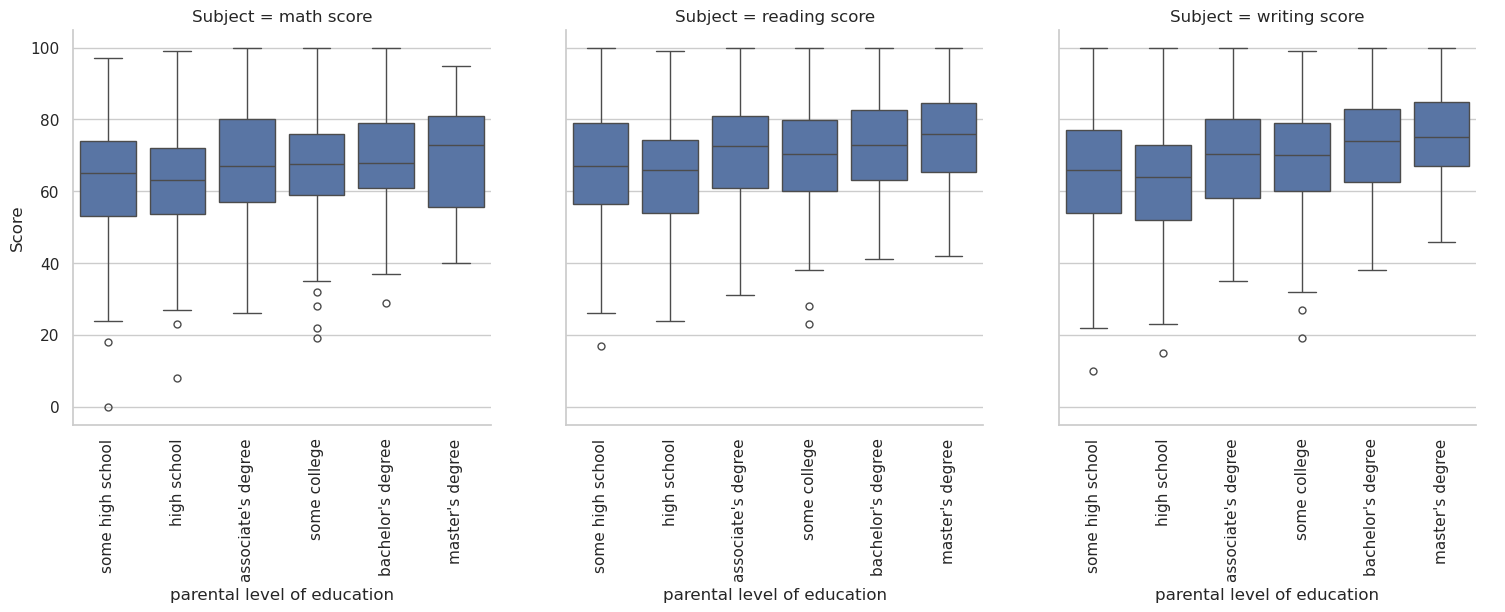

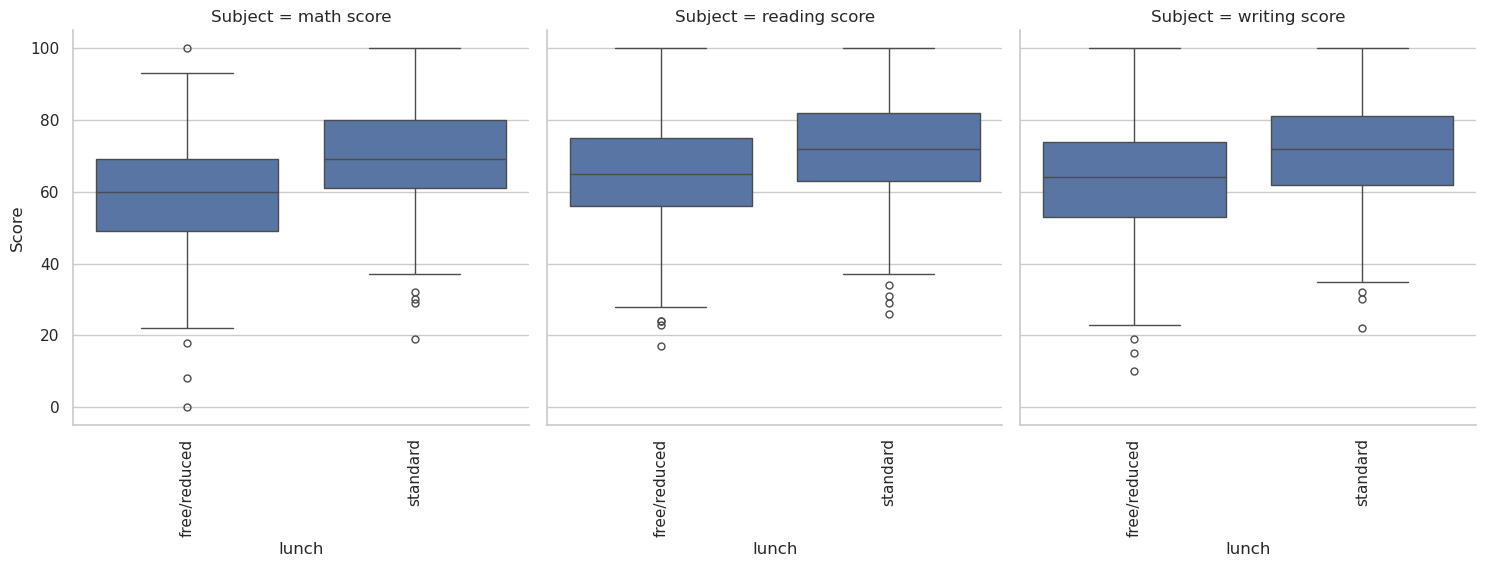

In [ ]:
#########################################################################
############### Question 3 ##############################################
#########################################################################

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

q3 = pd.read_csv("Question3.csv")

#### Preparing the data ####
q3["gender"] = q3["gender"].astype("category")
q3["race/ethnicity"] = q3["race/ethnicity"].astype("category")

# Ordered categorical
edu_order = [
    "some high school",
    "high school",
    "associate's degree",
    "some college",
    "bachelor's degree",
    "master's degree"
]

q3["parental level of education"] = pd.Categorical(
    q3["parental level of education"],
    categories=edu_order,
    ordered=True
)

q3["lunch"] = q3["lunch"].astype("category")
q3["test preparation course"] = q3["test preparation course"].astype("category")


#### Part A ####
# Select score columns (equivalent to q3[,6:8])
q3a = q3.iloc[:, 5:8]

# Correlation matrix
rcor = q3a.corr()

# Plot correlation (numbers like corrplot(method="number"))
plt.figure()
sns.heatmap(rcor, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Compute correlation + p-values (like Hmisc::rcorr)
from scipy.stats import pearsonr

corr_matrix = q3a.corr()
p_matrix = pd.DataFrame(np.ones_like(corr_matrix), columns=corr_matrix.columns, index=corr_matrix.index)

for col1 in q3a.columns:
    for col2 in q3a.columns:
        if col1 != col2:
            r, p = pearsonr(q3a[col1], q3a[col2])
            p_matrix.loc[col1, col2] = p

print("Correlation (r):")
print(corr_matrix.round(4))

print("\nP-values:")
print(p_matrix.round(4))

# The correlation plot shows highly correlated variables ranging between
# 0.8 and 0.95. The test of significance suggests
# statistically significant bivariate relations between the three variables


#### Part B ####
# Pivot longer (melt)
q3_long = q3.melt(
    id_vars=["parental level of education"],
    value_vars=["math score", "reading score", "writing score"],
    var_name="Subject",
    value_name="Score"
)
  
# Plot
g = sns.catplot(
    data=q3_long,
    x="parental level of education",
    y="Score",
    col="Subject",
    kind="box",
    sharey=True
)

g.set_xticklabels(rotation=90)
plt.show()

# The distribution of the scores in the boxplots suggests 
# no association between the parental level of education 
# and the score in any of the three subjects.


#### Part C ####
# Reuse melted data but with lunch
q3_long2 = q3.melt(
    id_vars=["lunch"],
    value_vars=["math score", "reading score", "writing score"],
    var_name="Subject",
    value_name="Score"
)

# Plot
g = sns.catplot(
    data=q3_long2,
    x="lunch",
    y="Score",
    col="Subject",
    kind="box",
    sharey=True
)

g.set_xticklabels(rotation=90)
plt.show()

# The distribution of the scores in the boxplots suggests 
# association between the type of lunch and the score. 
# Standard lunch has higher median in all subjects.